# Analysis notebook for the IVU Transverse Impedance measurement

The goal of this notebook is to explore the data during the IVU transverse impedance machine study and progressively extract the quantities needed to estimate the transverse kick factor.

The analysis follows a simple path:

1. Load the data files.
2. Build bunch-to-bunch orbit differences:

\begin{equation}
\Delta u = u_{\rm high} - u_{\rm low},
\qquad u=x,y.
\end{equation}

3. Build current-normalized / charge-normalized orbit differences:

\begin{equation}
\Delta u_{\rm norm}
=
\frac{\Delta u}{\Delta q}.
\end{equation}

4. Check the consistency of the data across turns and acquisitions.
5. Study how $\Delta u$ and $\Delta u/\Delta q$ evolve with the bump $y_0$.
6. Fit the BPM-vector pattern to extract the IVU kick factor for each gap.

The final experimental quantity of interest is the transverse kick factor (in each plane) as a function of gap:

\begin{equation}
k_\perp(g).
\end{equation}

All variables and plots will employ *usual units*:

- orbit positions: µm
- kicks (θ): µrad
- currents: mA
- charges: nC
- IVU gaps: mm
- bumps (y0): mm
- spos: m

## Imports

In [338]:
# %matplotlib qt5
%matplotlib inline

import os
import sys
import pickle
import importlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mathphys.functions import load

parent_dir = os.path.dirname(os.getcwd())
ivu_orm_dir = os.path.join(parent_dir, "ivu_kick_respmat")
sys.path.append(ivu_orm_dir)

from ivu_orm import calc_ivu_orm
import analysis_utils_newdata as utils

## Paths and Loading

Data description:

Each loaded file returns one dictionary `data_i` with the structure:
```
data_i = {
    "params": {...},
    "data": {...},
}
```
corresponding to a measurement at one IVU gap value, one vertical bump value, and for even or odd BPMs.

`"params"` is a dictionary containing fixed quantities which were pre-defined for that specific measurement, for example:

- `num_acquisitions` $\,$ *[]*
- `_nrturns` $\,$ *[]*


On the other hand, `"data"` is a list of *len=num_acquisitions*, where each element is a dictionary containing measured quantities. These include:

- `b1_posx` $\,$ *(n_bpms/2, n_turns)* $\,$ *[µm]*
- `b1_posy`
- `b1_sum` $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ ...
- `b2_posx` $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ ...
- `b2_posy`
- `b2_sum` $\;$ $\,$ *(n_bpms/2, n_turns)* $\,$ *[µm]*

_

- `timestamp` $\,$ *[]*
- `sofb_refx` $\,$ *(n_bpms/2,)* $\,$ *[µm]*
- `sofb_refy` $\,$ *(n_bpms/2,)* $\,$ *[µm]*
- `sofb_orbx` $\,$ *(n_bpms/2,)* $\,$ *[µm]*
- `sofb_orby` $\,$ *(n_bpms/2,)* $\,$ *[µm]*
- `ivu18_08_gap` $\,$ *[mm]*
- `ivu18_14_gap` $\,$ *[mm]*

_

- `stored_current` $\,$ *[mA]*
- `b1_curr` $\,$ *[mA]*
- `b2_curr` $\,$ *[mA]*

Here, *n_bpms* = 160.

In theory, `b1_sum` and `b2_sum` should be *(n_bpms/2, n_turns)* arrays, as they correspond to a sum of the signal over the 4 antennas:

$\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ *b_sigs*  $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$ $\;$  ->  $\;$ $\;$ $\,$ $\,$ $\;$ $\;$ $\;$ $\;$ *b_sum*

*(4, n_bpms/2, n_turns)*  $\;$ $\;$ -> $\;$ $\;$ *(n_bpms/2, n_turns)* 

However, we've accidentally summed the signals over axis(-1), i.e., the over the turns per acquisition, resulting in shapes *(4, n_bpms/2)*. Consequently, `b1_curr` and `b2_curr` also inherited the same shape, and were calculated wrongly.

Because of this, before beginning the analysis we first correct these `b_curr` values, opting to have them as floats $-$ i.e., `b1_curr` and `b2_curr` correspond to the mean value of these currents across all available BPMs and turns (just like `stored_current`, they will present one value per acquisition).

Furthermore, we also calculate and add to `data[i]['data'][#acq]` the current difference between bunches, `delta_curr`, and the charge-equivalent quantities `b1_charge`, `b2_charge` and `delta_charge`.

Another important point is the addition of a key `y_0` to `data[i]['params']`, to store the vertical bump value in mm (taken from the file name).

### Paths

In [339]:
# Define data paths 
data_dir = os.path.join('/mnt', 'shared', 'screens-iocs', 
    'data_by_day', '2026-08-24-SI_IVU_impedance_measurement'
)

In [340]:
gaps = ['4p300mm']
bumps = ['m1000um', 'm0500um', 'p0000um', 'p0500um', 'p1000um']

file_paths = [
    data_dir + '/' + f'ivu_08_gap_{gap}_bump_y_{bump}_yp_p0000urad_acq_n0.pickle'
    for gap in gaps
    for bump in bumps
]

bumps_numeric = [-1.0, -0.5, 0.0, 0.5, 1.0]  # [mm]

bumps_of_files = [
    bump_numeric
    for gap in gaps
    for bump_numeric in bumps_numeric
]

half_lim = int(len(file_paths) / 2)

print("Gap 4.3 mm:")
for file_path, bump_of_file in zip(
    file_paths, bumps_of_files,
):
    print(file_path, f"| y0 = {bump_of_file:.2f} mm")


Gap 4.3 mm:
/mnt/shared/screens-iocs/data_by_day/2026-08-24-SI_IVU_impedance_measurement/ivu_08_gap_4p300mm_bump_y_m1000um_yp_p0000urad_acq_n0.pickle | y0 = -1.00 mm
/mnt/shared/screens-iocs/data_by_day/2026-08-24-SI_IVU_impedance_measurement/ivu_08_gap_4p300mm_bump_y_m0500um_yp_p0000urad_acq_n0.pickle | y0 = -0.50 mm
/mnt/shared/screens-iocs/data_by_day/2026-08-24-SI_IVU_impedance_measurement/ivu_08_gap_4p300mm_bump_y_p0000um_yp_p0000urad_acq_n0.pickle | y0 = 0.00 mm
/mnt/shared/screens-iocs/data_by_day/2026-08-24-SI_IVU_impedance_measurement/ivu_08_gap_4p300mm_bump_y_p0500um_yp_p0000urad_acq_n0.pickle | y0 = 0.50 mm
/mnt/shared/screens-iocs/data_by_day/2026-08-24-SI_IVU_impedance_measurement/ivu_08_gap_4p300mm_bump_y_p1000um_yp_p0000urad_acq_n0.pickle | y0 = 1.00 mm


### Loading

Load all measured data and add bump ($y_0$) information

In [341]:
data = []

for file_path, bump_of_file in zip(file_paths, bumps_of_files):
    data_i = load(file_path)
    data_i["params"]["y0"] = bump_of_file  # [mm]
    data.append(data_i)

n_configs = len(data)  # []

print(f"Loaded {n_configs} configurations.")

Loaded 5 configurations.


### Add charges information

In [342]:
data = utils.calculate_currents(data)
data = utils.add_charge_information(data)

### Join even and odd BPM data

In [343]:
data_joined = utils.join_odd_even_acquisitions(data)
data_sel = data_joined

Check

In [344]:
print("Raw first sub-acq bpm_indices:", data[0]["data"][0]["bpm_indcs"][:15])
print("Raw second sub-acq bpm_indices:", data[0]["data"][1]["bpm_indcs"][:15])
print("Joined bpm_indices:", data_joined[0]["data"][0]["bpm_indcs"][:30])

Raw first sub-acq bpm_indices: [ 0  4  8 12 16 20 24 28 32 36 40 44 48 52 56]
Raw second sub-acq bpm_indices: [ 2  6 10 14 18 22 26 30 34 38 42 46 50 54 58]
Joined bpm_indices: [ 0  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38 40 42 44 46
 48 50 52 54 56 58]


In [345]:
print("Before joining:")
print("n sub-acq:", len(data[1]["data"]))
print("b1_posy shape:", data[1]["data"][0]["b1_posy"].shape)
print("first bpm index:", data[1]["data"][0]["bpm_indcs"][0])

print("\nAfter joining:")
print("n acq:", len(data_joined[1]["data"]))
print("b1_posy shape:", data_joined[1]["data"][0]["b1_posy"].shape)
print("bpm_indcs shape:", np.shape(data_joined[1]["data"][0]["bpm_indcs"]))

print("Before joining:")
print("n sub-acq:", len(data[0]["data"]))
print("b1_posy shape:", data[0]["data"][0]["b1_posy"].shape)
print("first bpm index:", data[0]["data"][0]["bpm_indcs"][0])

print("\nAfter joining:")
print("n acq:", len(data_joined[0]["data"]))
print("b1_posy shape:", data_joined[0]["data"][0]["b1_posy"].shape)
print("bpm_indcs shape:", np.shape(data_joined[0]["data"][0]["bpm_indcs"]))

print("\nMetadata:")
print("parity:", data_joined[1]["params"]["parity"])
print("mode:", data_joined[1]["params"]["acquisition_mode"])

Before joining:
n sub-acq: 10
b1_posy shape: (80, 500)
first bpm index: 0

After joining:
n acq: 5
b1_posy shape: (160, 500)
bpm_indcs shape: (160,)
Before joining:
n sub-acq: 10
b1_posy shape: (40, 500)
first bpm index: 0

After joining:
n acq: 5
b1_posy shape: (80, 500)
bpm_indcs shape: (80,)

Metadata:
parity: all
mode: odd_even_joined


## First data checks

In [346]:
data_i_check = data_joined[1]

data_i_check_params = data_i_check["params"]
data_i_check_meas = data_i_check["data"]
data_i_check_acq = data_i_check_meas[0]

print("\ndata[i] keys:")
print(data_i_check.keys())

print("\n'params' keys:")
print(data_i_check_params.keys())

print("\n'data'[acq] keys:")
print(data_i_check_acq.keys())


data[i] keys:
dict_keys(['data', 'params'])

'params' keys:
dict_keys(['trigbpm_delay', 'trigbpm_nrpulses', 'do_pulse_evg', '_timing_event', 'event_delay', 'event_mode', 'timeout', 'nrpoints_before', 'nrpoints_after', 'acq_rate', 'acq_repeat', 'signals2acq', 'acq_strategy', 'num_acquisitions', 'save_raw_data', 'num_buckets_to_process', '_nrturns', 'bucket_hi_charge', 'bucket_lo_charge', 'y0', 'parity', 'acquisition_mode'])

'data'[acq] keys:
dict_keys(['ispost_mortem', 'timestamp', 'rf_frequency', 'stored_current', 'tunex', 'tuney', 'acq_rate', 'sampling_frequency', 'nrsamples_pre', 'nrsamples_post', 'trig_delay_raw', 'switching_mode', 'switching_frequency', 'tunex_acq_enable', 'tuney_acq_enable', 'tunex_exc_enable', 'tuney_exc_enable', 'bpm_names', 'bpm_indcs', 'sofb_refx', 'sofb_refy', 'sofb_orbx', 'sofb_orby', 'sofb_bpmxenbl', 'sofb_bpmyenbl', 'sofb_nr_points', 'sofb_kickch', 'sofb_kickcv', 'sofb_kickrf', 'ivu18_08_gap', 'ivu18_14_gap', 'acq_group', 'b1_posx', 'b1_posy', 'b1_sum', 

In [347]:
print('\nOne acquisition:')

print("\nShapes:")
print("b1_posx:", np.shape(data_i_check_acq["b1_posx"]))
print("b1_posy:", np.shape(data_i_check_acq["b1_posy"]))
print("b2_posx:", np.shape(data_i_check_acq["b2_posx"]))
print("b2_posy:", np.shape(data_i_check_acq["b2_posy"]))

print("\nConfiguration:")
print(rf"IVU SI_08 gap: {data_i_check_acq['ivu18_08_gap']:.2f} mm")
print(rf"IVU SI_14 gap: {data_i_check_acq['ivu18_14_gap']:.2f} mm")
print(rf"y0           : {data_i_check_params['y0']:.2f} mm")
print(rf"n_acq        : {data_i_check_params['num_acquisitions']}")
print(rf"n_turns      : {data_i_check_params['_nrturns']}")
print(rf"parity       : {data_i_check_params['parity']}")

print("\nCurrents and charges:")
print(rf"Bunch 1 current: {data_i_check_acq['b1_curr']:.3f} mA     |     Bunch 1 charge: {data_i_check_acq['b1_charge']:.3f} nC")
print(rf"Bunch 2 current: {data_i_check_acq['b2_curr']:.3f} mA     |     Bunch 2 charge: {data_i_check_acq['b2_charge']:.3f} nC")
print(rf"Delta current  : {data_i_check_acq['delta_curr']:.3f} mA     |     Delta charge  : {data_i_check_acq['delta_charge']:.3f} nC")
print(rf"Mean Delta charge (across acquisitions): {data_i_check_acq['delta_charge_mean']:.3f} nC")


One acquisition:

Shapes:
b1_posx: (160, 500)
b1_posy: (160, 500)
b2_posx: (160, 500)
b2_posy: (160, 500)

Configuration:
IVU SI_08 gap: 4.30 mm
IVU SI_14 gap: 24.00 mm
y0           : -0.50 mm
n_acq        : 5
n_turns      : 500
parity       : all

Currents and charges:
Bunch 1 current: 1.007 mA     |     Bunch 1 charge: 1.740 nC
Bunch 2 current: 0.199 mA     |     Bunch 2 charge: 0.345 nC
Delta current  : 0.807 mA     |     Delta charge  : 1.396 nC
Mean Delta charge (across acquisitions): 1.390 nC


## Create a configuration table

In [348]:
delta_q_group_step_nC = 0.5  # [nC]

config_table = utils.make_config_table(
    data_sel,
    gap_key="ivu18_08_gap",
    delta_q_group_step_nC=delta_q_group_step_nC,
)

config_table

,cfg,gap,y0,parity,n_acq,n_bpms,n_turns,delta_charge,delta_q_group,delta_q_group_nC,b1_curr,b2_curr,delta_curr
0,0,4.3,-1.0,all,5,80,500,1.624655,3,1.5,1.136886,0.197324,0.939562
1,1,4.3,-0.5,all,5,160,500,1.389609,3,1.5,1.002928,0.199297,0.803631
2,2,4.3,0.0,all,5,160,500,1.535855,3,1.5,1.092621,0.204414,0.888208
3,3,4.3,0.5,all,5,160,500,1.447462,3,1.5,1.038351,0.201263,0.837088
4,4,4.3,1.0,all,5,80,500,1.596235,3,1.5,1.119670,0.196544,0.923126


### Visualize current distribution across acquisitions

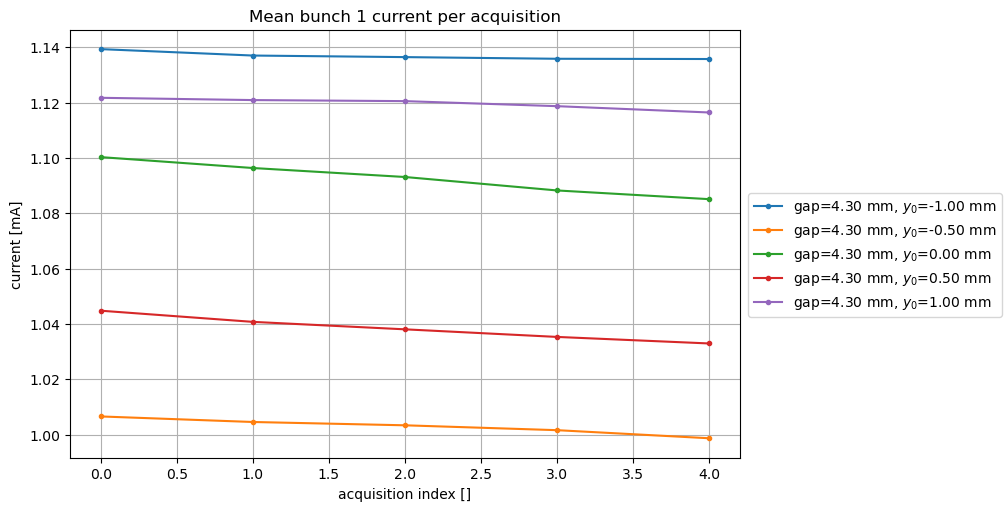

In [349]:
utils.plot_currents_vs_acquisition(data_sel, config_table, bunch=1, cfgs=range(5))

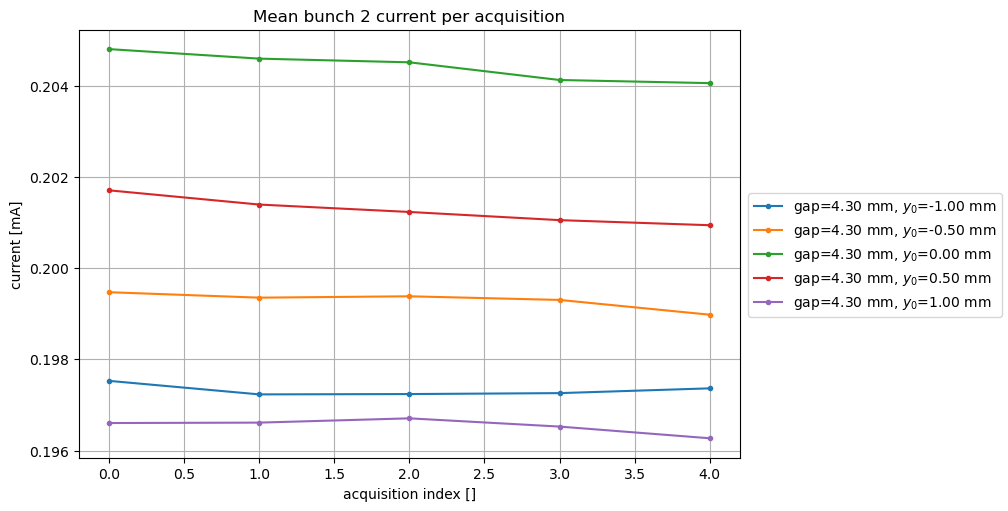

In [350]:
utils.plot_currents_vs_acquisition(data_sel, config_table, bunch=2, cfgs=range(5))

## Build orbit-difference arrays

For each configuration, the bunch $x$ and $y$ positions (${x_1}$, ${x_2}$, ${y_1}$, ${y_2}$) have shape:

\begin{equation}
(n_{\rm acq},\, n_{\rm bpms},\, n_{\rm turns}).
\end{equation}

After stacking all configurations, the corresponding orbit arrays have shape:

\begin{equation}
(n_{\rm configs},\, n_{\rm acq},\, n_{\rm bpms},\, n_{\rm turns}).
\end{equation}

We then define:

\begin{equation}
\Delta x = x_1 - x_2,
\qquad
\Delta y = y_1 - y_2.
\end{equation}

We also define the charge-normalized quantities:

\begin{equation}
\Delta x_{\rm norm} = \frac{\Delta x}{\Delta q},
\qquad
\Delta y_{\rm norm} = \frac{\Delta y}{\Delta q}.
\end{equation}

To generalize for both planes, we can call these orbit differences $\Delta u$ and $\Delta u_{\rm norm}$, which will be the names used throught this notebook.

The orbit differences are kept in $\mu\mathrm{m}$, while the charge-normalized ones are kept in $\mu\mathrm{m}/\mathrm{nC}$.

 Get full Delta u arrays

In [351]:
b1_ypos, b2_ypos, delta_ypos = utils.stack_orbit_data(data_sel, plane="y")
b1_xpos, b2_xpos, delta_xpos = utils.stack_orbit_data(data_sel, plane="x")

delta_ypos_norm = utils.normalize_by_charge(delta_ypos, config_table)
delta_xpos_norm = utils.normalize_by_charge(delta_xpos, config_table)

print("delta_ypos shape      :", len(delta_ypos), 'x', delta_ypos[0].shape)
print("delta_ypos_norm shape :", len(delta_ypos_norm), 'x', delta_ypos_norm[0].shape)
print("delta_xpos shape      :", len(delta_xpos), 'x', delta_xpos[0].shape)
print("delta_xpos_norm shape :", len(delta_xpos_norm), 'x', delta_xpos_norm[0].shape)

delta_ypos shape      : 5 x (5, 80, 500)
delta_ypos_norm shape : 5 x (5, 80, 500)
delta_xpos shape      : 5 x (5, 80, 500)
delta_xpos_norm shape : 5 x (5, 80, 500)


## First plots

### Helpers

### One configuration, acquisition and turn

Considering the full position displacement vector for the plane $u$, $\mathbf{\Delta u}$, we can write the element corresponding to configuration $c$, acquisition $i$, BPM $j$, and turn $k$, as:

\begin{equation}
\Delta u(c,i,j,k),
\end{equation}

Then, to begin, let's select one configuration, acquisition and turn (i.e., fixed $c$, $i$, and $k$), and plot the full $\Delta u_{c,i,k} (j)$ profile across the ring. 

First, we can quickly get ``spos_bpms`` using the _calc_ivu_orm_ function, which will be handful for the plots.

In [352]:
_, orm_info = calc_ivu_orm(delta_vkick=5e-6, ivu_number=1)

spos_bpms = orm_info["spos_bpms"]  # [m]

print("spos_bpms shape:", spos_bpms.shape)

spos_bpms shape: (160,)


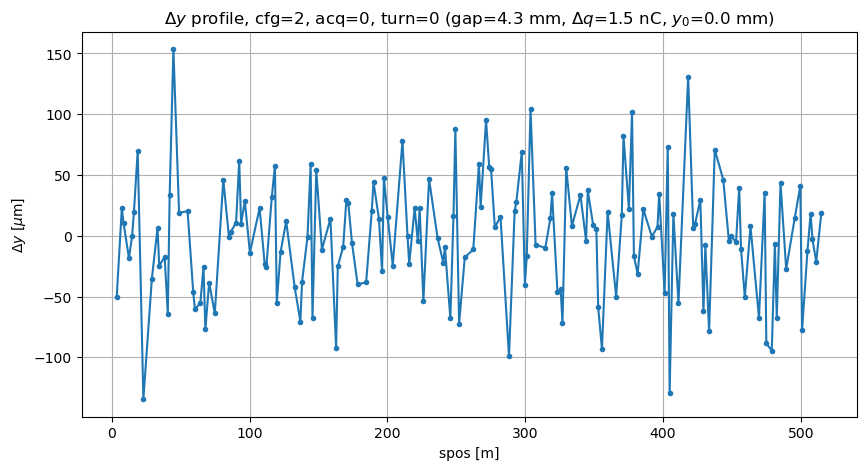

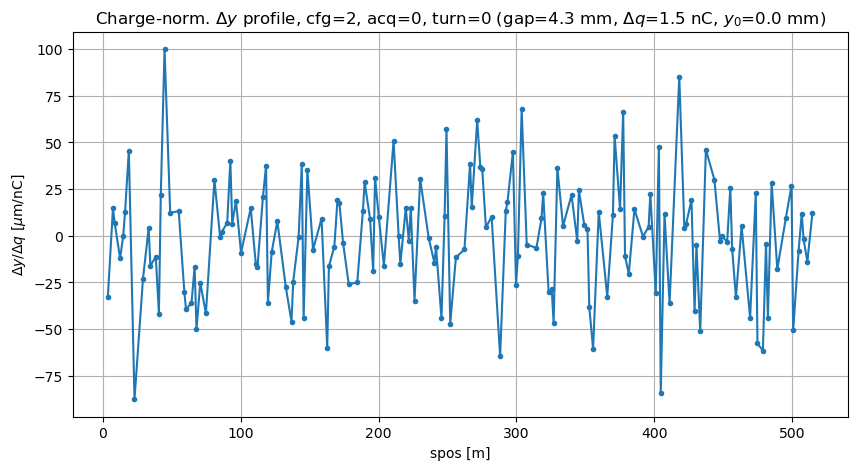

In [353]:
utils.plot_single_profile(data_sel, config_table, spos_bpms, cfg=2, acq=0, turn=0, plane="y", normalized=False)
utils.plot_single_profile(data_sel, config_table, spos_bpms, cfg=2, acq=0, turn=0, plane="y", normalized=True)

### One Configuration and one aquisition

Now, let's overlay orbits from multiple turns from one acquisition $-$ meaning: plot $\Delta u_{c,i,k} (j)$ for some selected $k's$.

*It can help us see if the turn-to-turn fluctuations are small, or if the full BPM profile changes significantly inside one acquisition.*

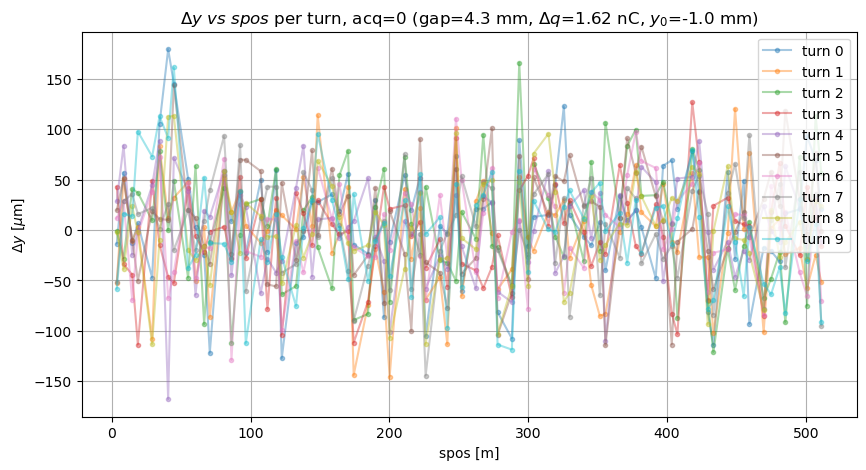

In [354]:
utils.plot_turns_in_acquisition(data_sel, config_table, spos_bpms, cfg=0, acq=0, turns=range(10), plane="y", normalized=False, legend=True)

We can also see the turn-distribution for a single BPM.

(i.e., plot $\Delta u_{c,i,j}(k)$)

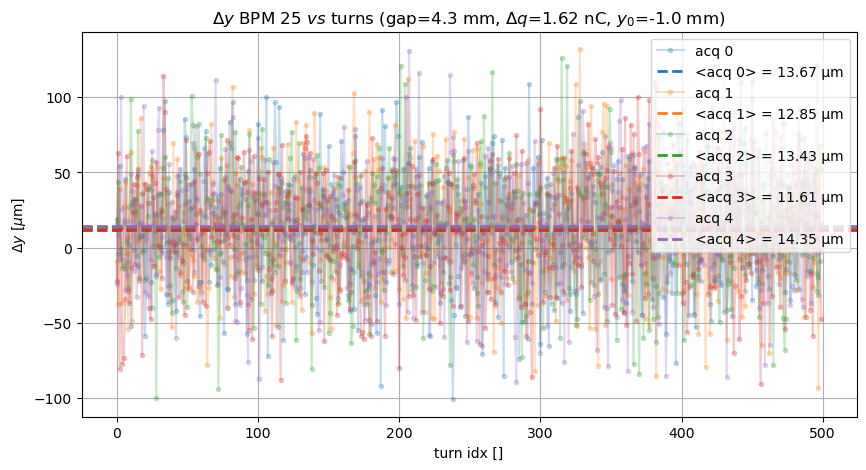

In [355]:
utils.plot_one_bpm_for_acquisitions(data_sel, config_table, spos_bpms, cfg=0, acqs=range(5), bpm=25, normalized=False, alpha=0.25)

### Mean profile per acquisition

For each acquisition, we can average over turns (index $k$):

\begin{equation}
\langle \Delta u \rangle_{\rm turns}(c,i,j)
=
\langle \Delta u \rangle_{\rm k}(c,i,j)
=
\frac{1}{n_{\rm turns}}
\sum_k
\Delta u(c,i,j,k).
\end{equation}

And also calculate the corresponding $std$:

\begin{equation}
\mathrm{std}_{k}
\left[
\Delta u(c,i,j,k)
\right],
\end{equation}

which can give a first estimate of the stability inside each acquisition.

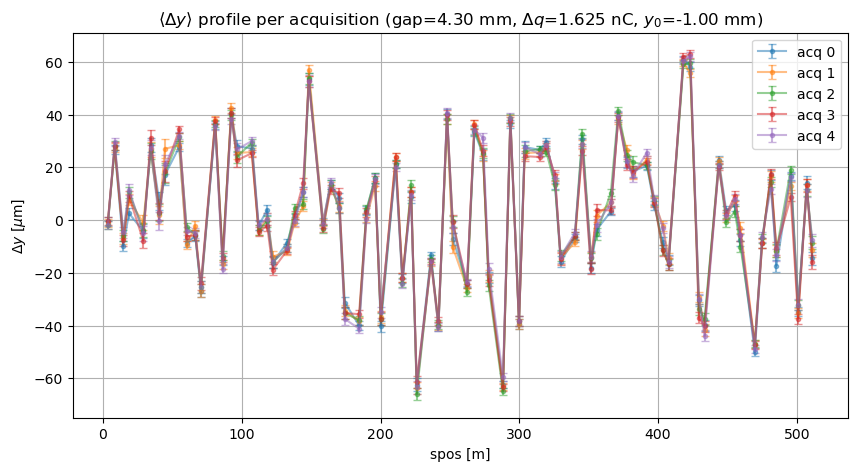

In [356]:
utils.plot_acquisition_means(data_sel, config_table, spos_bpms, cfg=0, plane="y", acqs=range(0,5), normalized=False, error_bars=True, error_par='sem', legend=True)

### Mean profile for one configuration

Now, for each configuration, we can average over all acquisitions and turns:

\begin{equation}
\overline{\Delta u}(c,j)
=
\left\langle \Delta u \right\rangle_{i,k}(c,j) = 
\frac{1}{n_{\rm acq}n_{\rm turns}} \sum_{i,k} \Delta u(c,i,j,k).
\end{equation}

_(reminder: $c$ refers to config. index, $i$ to acquisition index, $j$ to BPM index, and $k$ to turn index)_

And we also calculate the standard deviation:

\begin{equation}
\sigma_{\Delta u}(c,j)
=
\mathrm{std}_{i,k}
\left[
\Delta u(c,i,j,k)
\right].
\end{equation}

**Resulting in arrays $\overline{\Delta u}$ and $\sigma_{\Delta u}$ of dimensions** (*n_configs, n_bpms*) **, which will be central for the subsequent analyses.**

In [357]:
delta_y_proc = utils.process_delta_u(delta_ypos)
delta_y_proc_norm = utils.process_delta_u(delta_ypos_norm)

delta_x_proc = utils.process_delta_u(delta_xpos)
delta_x_proc_norm = utils.process_delta_u(delta_xpos_norm)

In [358]:
print(len(delta_y_proc['mean']), ',', delta_y_proc['mean'][0].shape[0])

5 , 80


Plot one (or some) processed configuration(s):

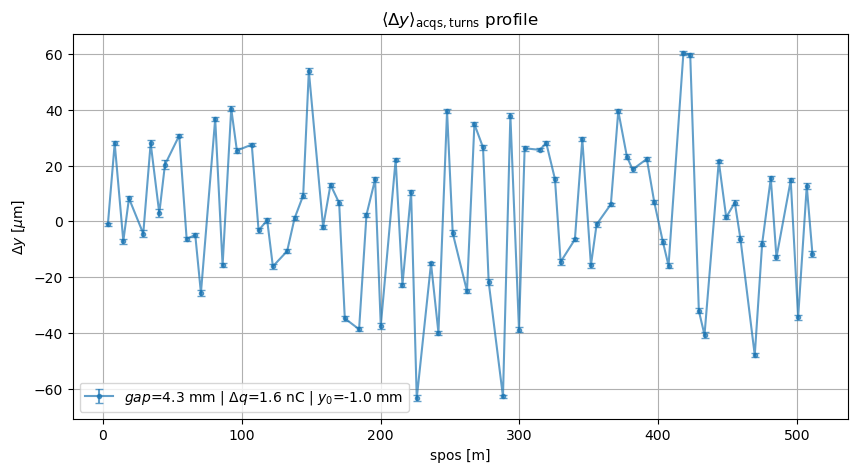

In [359]:
utils.plot_config_mean(data_sel, config_table, spos_bpms, cfgs=[0], plane="y", normalized=False)

In [360]:
importlib.reload(utils)

<module 'analysis_utils_newdata' from '/home/henrique.silvestre/fac-henrique/coding/machine_studies/measurement_run_and_analysis/analysis_utils_newdata.py'>

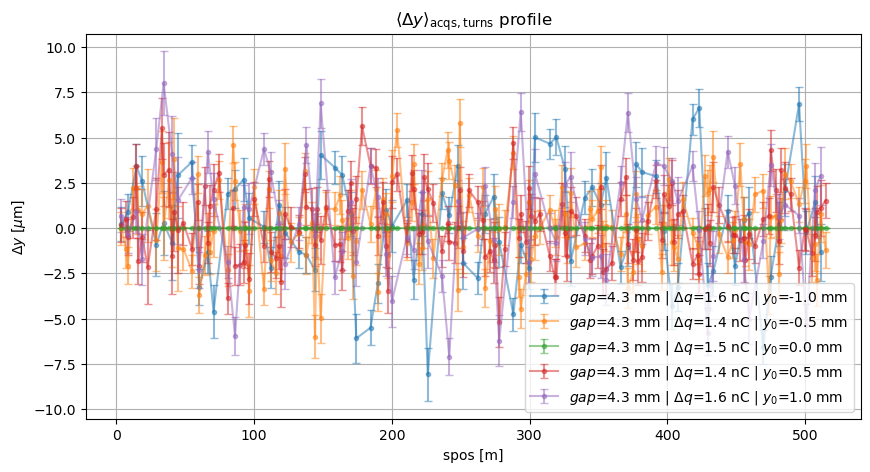

In [361]:
# %matplotlib qt5
%matplotlib inline

utils.plot_config_mean(data_sel, config_table, spos_bpms, cfgs=range(5), ref_cfg=2, plane="y", alpha=0.5)

### Single BPM view: $\overline{\Delta u}_i$ versus $y_0$

Before doing a fit for each configuration using all BPMs, it is useful to look at individual BPMs to see if $\overline{\Delta u}_i(\Delta q, y_0)$ follows the expected behavior.

For one BPM and one gap, we can plot:

\begin{equation}
    \overline{\Delta u_i}
\quad \text{vs} \quad y_0
\end{equation}

for different values of $\Delta q$. 

**We expect $\overline{\Delta u_i}$ to grow approx. linearly with both $\Delta q$ and $y_0$.**

Then, we'll plot:

\begin{equation}
\frac{\Delta u_i}{\Delta q}
\quad \text{vs} \quad y_0.
\end{equation}

And if the signal follows the expected charge dependence, curves with different $\Delta q$ should approximately collapse in the normalized plot!

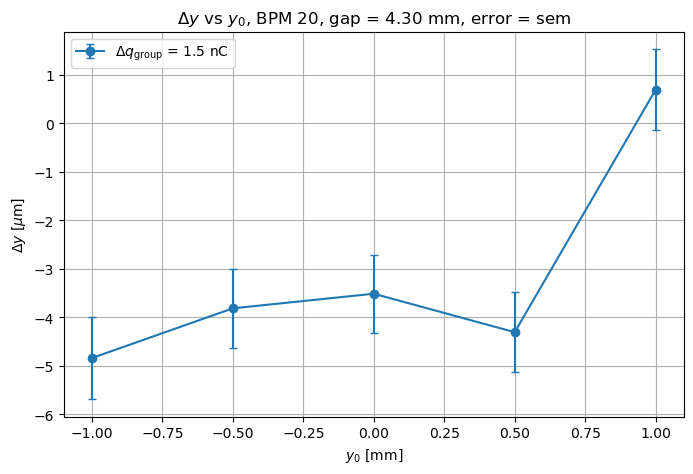

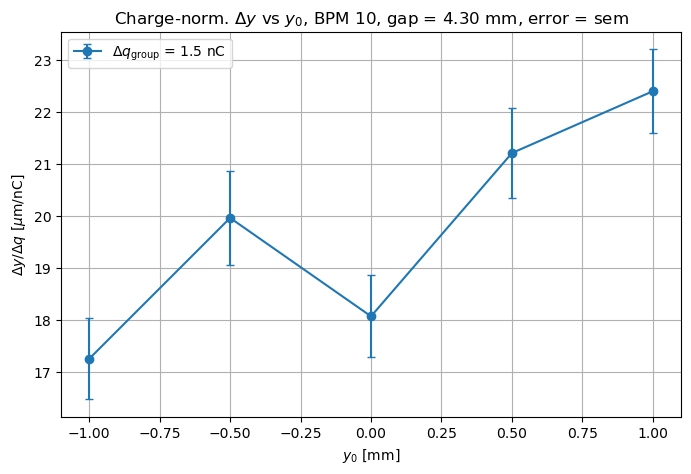

In [ ]:
utils.plot_delta_u_bpm_vs_y0(data_sel, config_table, bpm=20, gap=4.3, plane="y", normalized=False, error_par='sem')
utils.plot_delta_u_bpm_vs_y0(data_sel, config_table, bpm=10, gap=4.3, plane="y", normalized=True, error_par='sem')

## Global BPM-vector fit

Now, for each configuration, we want to estimate the equivalent kick angle produced at the IVU.

For one plane $u=x$ or $u=y$, we model the filtered orbit difference as:

\begin{equation}
\Delta \mathbf u_{\rm cfg}
=
\theta_{\rm cfg}^{u,\rm true}\mathbf M_{\rm IVU}^{u}
+
\mathbf b^u
+
\boldsymbol\eta_{\rm cfg}^u.
\end{equation}

Here:

- $\Delta \mathbf u_{\rm cfg}$ is the processed and filtered orbit-difference vector;
- $\mathbf M_{\rm IVU}^{u}$ is the orbit response vector of the IVU;
- $\theta_{\rm cfg}^{u,\rm true}$ is the true equivalent kick angle;
- $\mathbf b^u$ is a fixed BPM-by-BPM background;
- $\boldsymbol\eta_{\rm cfg}^u$ is random noise.

For each configuration, we estimate $\theta_{\rm cfg}^u$ by projecting $\Delta \mathbf u_{\rm cfg}$ onto $\mathbf M_{\rm IVU}^{u}$:

\begin{equation}
\widehat{\theta}_{\rm cfg}^u
=
\frac{
\left(\mathbf M_{\rm IVU}^{u}\right)^T
\Delta \mathbf u_{\rm cfg}
}{
\left(\mathbf M_{\rm IVU}^{u}\right)^T
\mathbf M_{\rm IVU}^{u}
}.
\end{equation}

Then we expect ($g$ denoting the gap):

\begin{equation}
\widehat{\theta}_{\rm cfg}^u
=
\theta_0^u
+
\frac{k_\perp^u(g)}{E/e}
\Delta q y_{0}
+
\mathrm{noise}.
\end{equation}

And normalizing by the charge difference:

\begin{equation}
\frac{\widehat{\theta}_{\rm cfg}^{u}}{\Delta q_{\rm cfg}}
=
\mathrm{offset}(\Delta q_{\rm cfg})
+
a^u(g)y_{0,\rm cfg}
+
\mathrm{noise}(\Delta q_{\rm cfg}),
\end{equation}

with:

\begin{equation}
a^u(g)
=
\frac{k_\perp^u(g)}{E/e}.
\end{equation}

Therefore, having many configurations of ($\Delta q, y_0$) for a certain gap, the corresponding kick factor can be obtained from the slope:

\begin{equation}
k_\perp^u(g)
=
(E/e)
a^u(g)
=
(E/e)
\frac{d}{dy_0}
\left(
\frac{\widehat{\theta}^{u}}{\Delta q}
\right).
\end{equation}

### Prepare processed $\Delta u$'s

In [362]:
delta_x_proc_mean = delta_x_proc["mean"]  # [µm]
delta_y_proc_mean = delta_y_proc["mean"]  # [µm]

delta_x_proc_err = delta_x_proc["sem"]  # [µm]
delta_y_proc_err = delta_y_proc["sem"]  # [µm]

### IVU response vectors

In [363]:
delta_x_proc['mean'][0].shape[0]

80

In [364]:
orm, orm_info = calc_ivu_orm(delta_vkick=5e-6, ivu_number=1)

M_ivu_x_cfgs, M_ivu_y_cfgs = utils.get_ivu_orms(orm, data_sel)

beam_voltage = 3.0e9  # [V]

print("delta_y_proc_mean shape :", (len(delta_y_proc_mean), delta_y_proc_mean[0].shape[0]))
print("M_ivu_y_cfgs shape      :", (len(M_ivu_y_cfgs), M_ivu_y_cfgs[0].shape[0]))
print("M_ivu_x_cfgs shape      :", (len(M_ivu_x_cfgs), M_ivu_x_cfgs[0].shape[0]))

delta_y_proc_mean shape : (5, 80)
M_ivu_y_cfgs shape      : (5, 80)
M_ivu_x_cfgs shape      : (5, 80)


### Orbit filtering

Before projecting the orbit difference onto the IVU response vector, we apply a filter that isolates the contribution of the IVU region.

For now, this function is only a placeholder. Later, it should be replaced by the real filtering function.

In [365]:
delta_x_filt = utils.filter_delta_u_ivu(
    delta_u_proc_mean=delta_x_proc["mean"],
    plane="x",
)

delta_y_filt = utils.filter_delta_u_ivu(
    delta_u_proc_mean=delta_y_proc["mean"],
    plane="y",
)

In [366]:
len(delta_x_filt), delta_x_filt[0].shape[0]

(5, 80)

### Projection onto the IVU response vector

For each configuration, we fit:

\begin{equation}
\Delta \mathbf u_{\rm cfg}
\approx
\widehat{\theta}_{\rm cfg}^{u}
\mathbf M_{\rm IVU}^{u}.
\end{equation}

This gives one scalar $\widehat{\theta}_{\rm cfg}^{u}$ per configuration.

The residual is:

\begin{equation}
\mathbf r_{\rm cfg}^{u}
=
\Delta \mathbf u_{\rm cfg}
-
\widehat{\theta}_{\rm cfg}^{u}
\mathbf M_{\rm IVU}^{u}.
\end{equation}

The residual contains the part of the orbit difference that is not proportional to the IVU response vector.

In [367]:
theta_x_fit = utils.fit_theta_u(
    delta_u_filt=delta_x_filt,
    M_ivu_u_cfgs=M_ivu_x_cfgs,
    delta_u_err=delta_x_proc["sem"],
)

theta_y_fit = utils.fit_theta_u(
    delta_u_filt=delta_y_filt,
    M_ivu_u_cfgs=M_ivu_y_cfgs,
    delta_u_err=delta_y_proc["sem"],
)

In [392]:
dq0 = config_table.loc[0, 'delta_charge']
dq2 = config_table.loc[2, 'delta_charge']
dq4 = config_table.loc[4, 'delta_charge']

In [432]:
%matplotlib qt5

dq0 = config_table.loc[0, 'delta_charge']
dq2 = config_table.loc[2, 'delta_charge']
dq4 = config_table.loc[4, 'delta_charge']

y_0_exp = delta_y_filt[0]/dq0
y_2_exp = delta_y_filt[2][::2]/dq2
y_4_exp = delta_y_filt[4]/dq4

y_0_model = theta_y_fit['model'][0]/dq0
y_2_model = theta_y_fit['model'][2][::2]/dq2
y_4_model = theta_y_fit['model'][4]/dq4

# Figure:

fig, (ax, ay) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

ax.plot(spos_bpms[::2], (y_0_exp-y_2_exp)*dq0, label='exp data ($y_0$ = -1 mm)')
ax.plot(spos_bpms[::2], y_2_exp-y_2_exp, label='exp data ($y_0$ = 0 mm)')
ax.plot(spos_bpms[::2], (y_4_exp-y_2_exp)*dq4, label='exp data ($y_0$ = +1 mm)')

ay.plot(spos_bpms[::2], (y_0_model-y_2_model)*dq0, label='model ($y_0$ = -1 mm)')
ay.plot(spos_bpms[::2], y_2_model-y_2_model, label='model ($y_0$ = -0 mm)')
ay.plot(spos_bpms[::2], (y_4_model-y_2_model)*dq4, label='model ($y_0$ = +1 mm)')

fig.suptitle(
    'Vertical orbit distortion between bunches\n'
    '($y_0 = 0$ mm orbit taken as reference)'
)
ax.set_ylabel(r'$\Delta y$ [$\mu$m]')
ay.set_ylabel(r'$\Delta y$ [$\mu$m]')
ay.set_xlabel(r'spos [m]')
ax.legend(loc='best')
ay.legend(loc='best')
ax.grid()
ay.grid()

plt.tight_layout()
fig.show()

In [434]:
dq1 = config_table.loc[1, 'delta_charge']
dq2 = config_table.loc[2, 'delta_charge']
dq3 = config_table.loc[3, 'delta_charge']

y_1_exp = delta_y_filt[1]/dq1
y_2_exp_full = delta_y_filt[2]/dq2
y_3_exp = delta_y_filt[3]/dq3

y_1_model = theta_y_fit['model'][1]/dq1
y_2_model_full = theta_y_fit['model'][2]/dq2
y_3_model = theta_y_fit['model'][3]/dq3

fig, (ax, ay) = plt.subplots(2, 1, sharex=True, figsize=(8, 6))

ax.plot(spos_bpms, (y_1_exp-y_2_exp_full)*dq1, label='exp data ($y_0$ = -0.5 mm)')
ax.plot(spos_bpms, y_2_exp_full-y_2_exp_full, label='exp data ($y_0$ = 0 mm)')
ax.plot(spos_bpms, (y_3_exp-y_2_exp_full)*dq3, label='exp data ($y_0$ = +0.5 mm)')

ay.plot(spos_bpms, (y_1_model-y_2_model_full)*dq1, label='model ($y_0$ = -0.5 mm)')
ay.plot(spos_bpms, y_2_model_full-y_2_model_full, label='model ($y_0$ = -0 mm)')
ay.plot(spos_bpms, (y_3_model-y_2_model_full)*dq3, label='model ($y_0$ = +0.5 mm)')

fig.suptitle(
    'Vertical orbit distortion between bunches\n'
    '($y_0 = 0$ mm orbit taken as reference)'
)
ax.set_ylabel(r'$\Delta y$ [$\mu$m]')
ay.set_ylabel(r'$\Delta y$ [$\mu$m]')
ay.set_xlabel(r'spos [m]')
ax.legend(loc='best')
ay.legend(loc='best')
ax.grid()
ay.grid()

plt.tight_layout()
fig.show()

In [435]:
fig, ax = plt.subplots()
ax.plot((y_0_exp - y_2_exp)*dq0, label='exp data')
ax.plot((y_0_model - y_2_model)*dq0, label='model')
ax.set_title(
    'Vertical orbit distortion ($y_0$ = -1 mm) - Exp. points and Model'
    '\n($y_{0, ref} = 0$ mm)'
)
ay.set_ylabel(r'$\Delta y$ [$\mu$m]')
ax.legend()
ax.grid()
fig.show()

In [436]:
fig, ax = plt.subplots()
ax.plot((y_1_exp - y_2_exp_full)*dq0, label='exp data')
ax.plot((y_1_model - y_2_model_full)*dq0, label='model')
ax.set_title(
    'Vertical orbit distortion ($y_0$ = -0.5 mm) - Exp. points and Model'
    '\n($y_{0, ref} = 0$ mm)'
)
ay.set_ylabel(r'$\Delta y$ [$\mu$m]')
ax.legend()
ax.grid()
fig.show()

### Projection check

In [302]:
importlib.reload(utils)

<module 'analysis_utils_newdata' from '/home/henrique.silvestre/fac-henrique/coding/machine_studies/measurement_run_and_analysis/analysis_utils_newdata.py'>

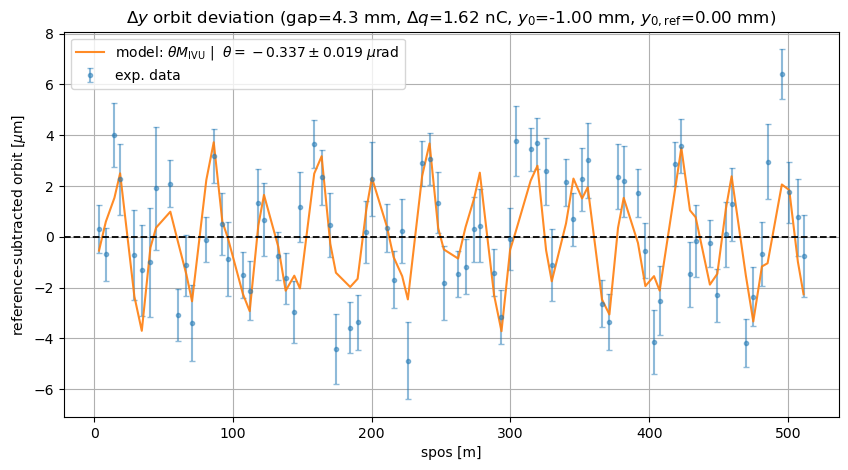

In [335]:
utils.plot_theta_projection(
    data=data_sel,
    config_table=config_table,
    spos_bpms=spos_bpms,
    delta_u_filt=delta_y_filt,
    delta_u_err=delta_y_proc["sem"],
    theta_fit=theta_y_fit,
    M_ivu_u_cfgs=M_ivu_y_cfgs,
    plane="y",
    cfg=0,
    ref_cfg=2,
    normalized=False,
)

### Plot projected kicks $\widehat{\theta}_{\rm cfg}^{u}$ vs $y_0$ before fit

After the projection, we have one fitted kick angle for each configuration:

\begin{equation}
\widehat{\theta}_{\rm cfg}^{u} \; = \; \widehat{\theta}^{u}(gap,\, \Delta q,\, y_0)
\end{equation}

Before extracting the kick factor, we can plot these values as a function of $y_0$ for different $gaps$ and $\Delta q$'s for visualization.

In [307]:
importlib.reload(utils)

<module 'analysis_utils_newdata' from '/home/henrique.silvestre/fac-henrique/coding/machine_studies/measurement_run_and_analysis/analysis_utils_newdata.py'>

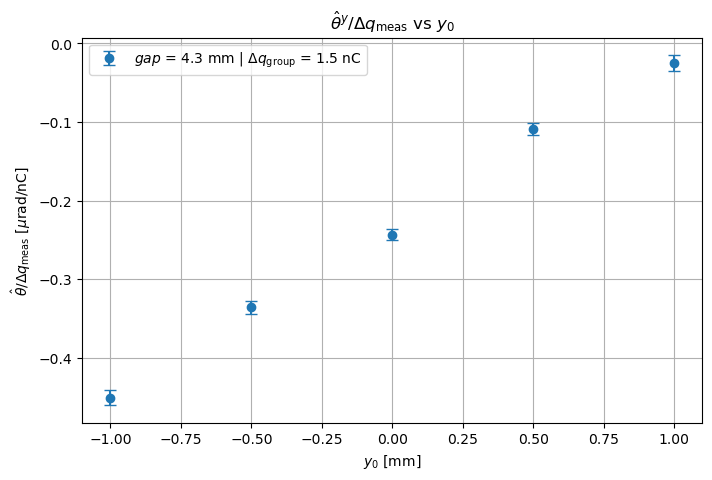

In [308]:
utils.plot_theta_values(
    config_table=config_table,
    theta_fit=theta_y_fit,
    gaps=[4.3],
    plane="y",
    normalized=True,
)

### Fit kick factor from $\widehat{\theta}$

For each configuration, we now have:

\begin{equation}
\widehat{\theta}_{\rm cfg}^{u}.
\end{equation}

For a fixed gap, we fit:

\begin{equation}
\frac{\widehat{\theta}_{\rm cfg}^{u}}{\Delta q_{\rm cfg}}
=
\mathrm{offset}(\Delta q_{\rm cfg})
+
a^u(g)y_{0,\rm cfg}.
\end{equation}

The slope is:

\begin{equation}
a^u(g)=\frac{k_\perp^u(g)}{E/e}.
\end{equation}

Select configurations

Linear fit with one offset per $\Delta q$

Ploting function (fit and exp. points)

### Testing one gap !

In [326]:
importlib.reload(utils)

<module 'analysis_utils_newdata' from '/home/henrique.silvestre/fac-henrique/coding/machine_studies/measurement_run_and_analysis/analysis_utils_newdata.py'>

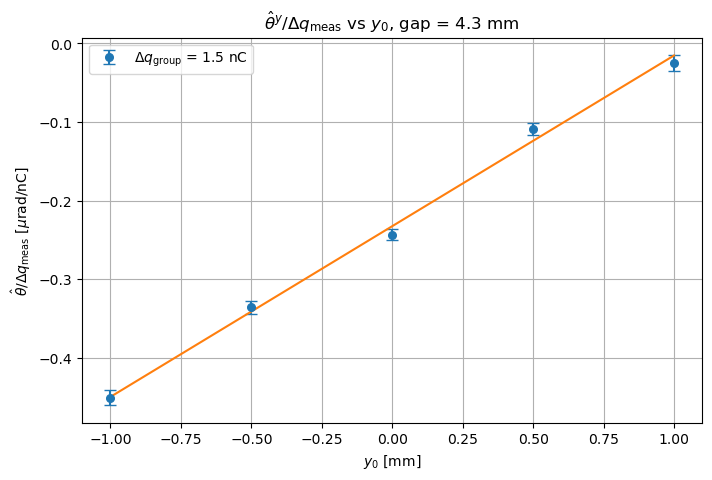

Kick-factor fit
---------------
plane     : y
gap       : 4.3 mm
n configs : 5

a         : 2.172e-01 +/- 5.825e-03 [urad/(nC mm)]
kperp     : 651.667 +/- 17.474 [V/(pC m)]
chi2/dof  : 2.456


In [322]:
kperp_y_gap43 = utils.fit_kperp_from_theta(
    config_table=config_table,
    theta_fit=theta_y_fit,
    gap=4.3,
    beam_voltage=3.0e9,
    delta_q_groups_nC=[1.5],
    delta_q_group_step_nC=delta_q_group_step_nC,
    plane="y",
)

utils.plot_theta_and_fit(kperp_y_gap43, normalized=True)
utils.print_kperp_summary(kperp_y_gap43)

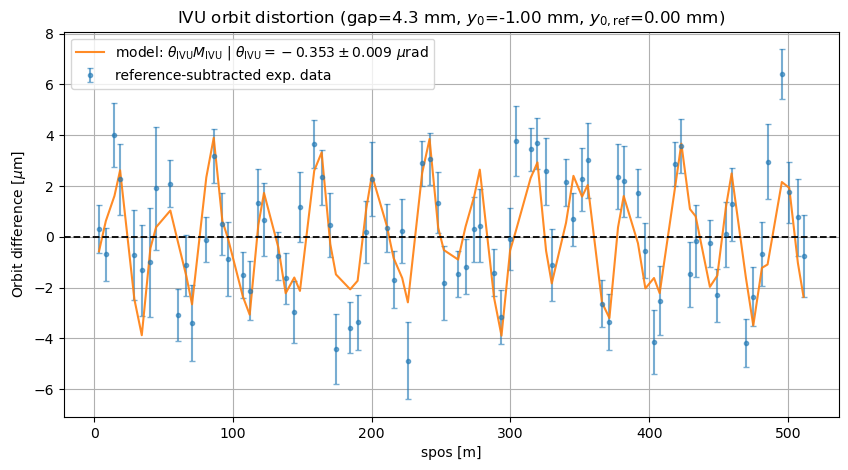

In [330]:
utils.plot_ivu_projection(
    data=data_sel,
    config_table=config_table,
    spos_bpms=spos_bpms,
    delta_u_filt=delta_y_filt,
    delta_u_err=delta_y_proc["sem"],
    M_ivu_u_cfgs=M_ivu_y_cfgs,
    kperp_fit=kperp_y_gap43,
    cfg=0,
    ref_cfg=2,
    plane="y",
    normalized=False,
)

### Fit all gaps and join results

Calculate fits of configurations of interest

In [ ]:
kperp_fits_y = [
    utils.fit_kperp_from_theta(
        config_table=config_table,
        theta_fit=theta_y_fit,
        gap=4.3,
        beam_voltage=3.0e9,
        delta_q_groups_nC=[1.5],
        delta_q_group_step_nC=delta_q_group_step_nC,
        plane="y",
    ),
    # utils.fit_kperp_from_theta(
    #     config_table=config_table,
    #     theta_fit=theta_y_fit,
    #     gap=8.6,
    #     beam_voltage=3.0e9,
    #     delta_q_groups_nC=[1.5],
    #     delta_q_group_step_nC=delta_q_group_step_nC,
    #     plane="y",
    # ),
]

Join results

In [ ]:
results_table_y = utils.make_kperp_results_table(
    kperp_fits=kperp_fits_y,
    labels=["gap4p3"],
)

results_table_y

,label,gap_mm,plane,delta_q_groups_nC,n_configs,dof,a_urad_per_nC_mm,a_err_urad_per_nC_mm,kperp_v_per_pC_m,kperp_err_v_per_pC_m
0,gap4p3,4.3,y,1.5,5,3,0.215805,0.007722,647.413727,23.165572


Display results

In [ ]:
results_table_y[[
    "label",
    "gap_mm",
    "kperp_v_per_pC_m",
    "kperp_err_v_per_pC_m",
    "delta_q_groups_nC",
    "n_configs"
]]

,label,gap_mm,kperp_v_per_pC_m,kperp_err_v_per_pC_m,delta_q_groups_nC,n_configs
0,gap4p3,4.3,680.488382,72.132515,1.5,3


### Plot kick factor vs gap

In [ ]:
utils.plot_kperp_vs_gap(results_table_y)

### Save processed fit results

In [ ]:
# processed_dir = os.path.join(os.path.dirname(data_dir), "processed")
# os.makedirs(processed_dir, exist_ok=True)

# results_table_y.to_csv(
#     os.path.join(processed_dir, "fit_results_y.csv"),
#     index=False,
# )

# with open(os.path.join(processed_dir, "fit_results_y.pickle"), "wb") as f:
#     pickle.dump(
#         {
#             "config_table": config_table,
#             "delta_y_proc": delta_y_proc,
#             "delta_y_filt": delta_y_filt,
#             "theta_y_fit": theta_y_fit,
#             "results_table_y": results_table_y,
#             "kperp_fits_y": kperp_fits_y,
#             "units": {
#                 "orbit": "um",
#                 "M_ivu": "um/urad",
#                 "theta": "urad",
#                 "charge": "nC",
#                 "y0": "mm",
#                 "gap": "mm",
#                 "a": "urad/(nC mm)",
#                 "kperp": "V/(pC m)",
#             },
#         },
#         f,
#     )

# print("Saved processed fit results in:")
# print(processed_dir)